<h2 style="color:violet" align= "center">Zudio sale performace analysis</h2>

<h2 style="color:green" align= "left">Introduction</h2>

## 
The world of fashion retail data might seem as unpredictable as the latest trends, yet there is always order hidden in the chaos. In this notebook, we will explore Zara's sales data through various lenses, aiming to extract meaningful insights and even predict revenue based on key variables. Our journey blends solid data science techniques with a touch of dry humor, because even in the most rigorous analysis, we could use a little wit.

## Phases

1. **Phase 1** — Environment Setup & Data Loading
2. **Phase 2** — Data Quality Assessment
3. **Phase 3** — Data Cleaning & Preprocessing
4. **Phase 4** — Exploratory Data Analysis (EDA)
5. **Phase 5** — Customer Segmentation (RFM)
6. **Phase 6** — Churn Analysis & Prediction
7. **Phase 7** — Upsale Opportunity Analysis

## Phase 1
# 
1.1 Environment setup importing required libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import kagglehub
import warnings

warnings.filterwarnings('ignore')
print("All libraries imported successfully")

All libraries imported successfully


### 1.2 Load the data

In [24]:
data= pd.read_csv(r"Zudio_sales_data.csv")


### 1.3 intial data inspection

In [25]:
print("First 5 rows:")
print(data.head())
print("=" * 80)

print("Data Info:")
print(data.info())
print("=" * 80)

print("Descriptive Statistics:")
print(data.describe(include='object'))
print("=" * 80)

print(f"Dataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")


First 5 rows:
   Store Country          State      City Category Clothing Type  \
0  Zudio   India      Karnataka     Jalna    Women       Dresses   
1  Zudio   India        Gujarat     Patna     Kids        Skirts   
2  Zudio   India  Uttar Pradesh   Kolkata      Men       Hoodies   
3  Zudio   India    West Bengal   Kolkata    Women       Dresses   
4  Zudio   India    West Bengal  Guwahati      Men       Dresses   

   Store Number  Postal Code Store Type Store Open Date  ...  \
0            30       411084      Owned      2022-06-04  ...   
1            48       404562      Owned      2020-12-19  ...   
2            97       437773     Rented      2023-09-04  ...   
3            93       431725      Owned      2024-04-11  ...   
4            51       415370      Owned      2022-05-29  ...   

   Security Features Order ID  Order Date     Month Customer ID  \
0              Alarm    88240  2024-11-06  November      233084   
1              Alarm    78145  2024-06-17      June      9

## Phase 2: Data Quality Assessment

###  2.1: Check Data Structure

#
Removing Unnecessary columns to reduce the complexity

In [26]:
data=data.drop(columns=['Store','Country','Postal Code','Manager ID','Store Address','Contact Information','Staff Count','Customer ID','Product ID','Store Type','Security Features'])

In [37]:
#Checking data types 
print("checking data types:")
print(data.dtypes)
print('=' * 100)

data['Store Open Date']=pd.to_datetime(data['Store Open Date'])
print(f"Date Range: {data['Store Open Date'].min()} to {data['Store Open Date'].max()}")
print(f"Period: {(data['Store Open Date'].max() - data['Store Open Date'].min()).days} days")
print("=" * 80)

print(f"Unique Customers: {data['Customer Name'].nunique():,}")
print(f"Unique products: {data['Clothing Type'].nunique():,}")
print(f"Unique cities: {data['City'].nunique():,}")

checking data types:
State                                object
City                                 object
Category                             object
Clothing Type                        object
Store Number                          int64
Store Open Date              datetime64[ns]
Selling Area Size (sq ft)             int64
Store Manager                        object
Operating Hours                      object
Parking Availability                 object
Order ID                              int64
Order Date                           object
Month                                object
Customer Name                        object
Price                                 int64
Quantity                              int64
Sales Profit                        float64
dtype: object
Date Range: 2020-01-01 00:00:00 to 2024-12-03 00:00:00
Period: 1798 days
Unique Customers: 7,499
Unique products: 11
Unique cities: 42


## 
2.2 missing values analysis

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7899 entries, 0 to 7898
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   State                      7899 non-null   object        
 1   City                       7899 non-null   object        
 2   Category                   7899 non-null   object        
 3   Clothing Type              7899 non-null   object        
 4   Store Number               7899 non-null   int64         
 5   Store Open Date            7899 non-null   datetime64[ns]
 6   Selling Area Size (sq ft)  7899 non-null   int64         
 7   Store Manager              7899 non-null   object        
 8   Operating Hours            7899 non-null   object        
 9   Parking Availability       7899 non-null   object        
 10  Order ID                   7899 non-null   int64         
 11  Order Date                 7899 non-null   object        
 12  Month 

##
There are no missing values in the data set

##
2.3 Duplicates check

In [48]:
dup= data.duplicated().sum()
print(f"duplicate rows:",{dup})

duplicate rows: {np.int64(0)}


##
Data does not contain any duplicate values

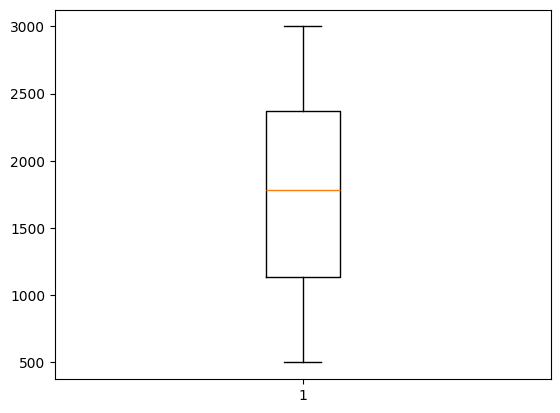

In [49]:
plt.boxplot(data['Price'])
plt.show()

## Phase 4: Exploratory Data Analysis (EDA)

### Step 4.1: Business Overview Metrics